# Model Selection — Accumulation Investment

Per-model outputs, ablation study, and statistical comparison for the **AccumulationInvestment** target.


In [1]:
import utils.preprocessing as prep

prep.TARGETS = ["AccumulationInvestment"]

from utils.show_results import show_xgboost, show_classifier_chain, show_hard_voting, show_logistic_reg, show_mlp, show_naive_bayes, show_soft_voting, show_random_forest


## Tier 1 — Interpretable baselines

### Logistic Regression

09:34:53  INFO      Training utils.linear_reg...
09:34:54  INFO      Target: AccumulationInvestment
09:34:54  INFO        Nested CV (F_E)...
09:35:44  INFO        [F_E] Nested CV F1: 0.693 ± 0.023
09:35:49  INFO        [F_E] Test F1=0.713  Precision=0.678  Brier=0.2226 (baseline=0.2498)
09:35:49  INFO        Nested CV (F_B ablation)...
09:35:51  INFO        [F_B] Test F1=0.695  (ΔF_E−F_B=+0.019)
09:35:51  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\linear_reg\accumulationinvestment.pkl



======== LogisticRegression  |  AccumulationInvestment ========

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_E — 10 engineered features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → clf__penalty = l1
    → clf__max_iter = 1000
    → clf__C = 1.0

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.2226  [no-skill: 0.2498]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.673 ± 0.026         0.690
  precision           0.668 ± 0.027         0.678
  recall              0.720 ± 0.029         0.752
  f1                  0.693 ± 0.023         0.713  ◄ PRIMARY
  ─────────────────────────────────────────────────────

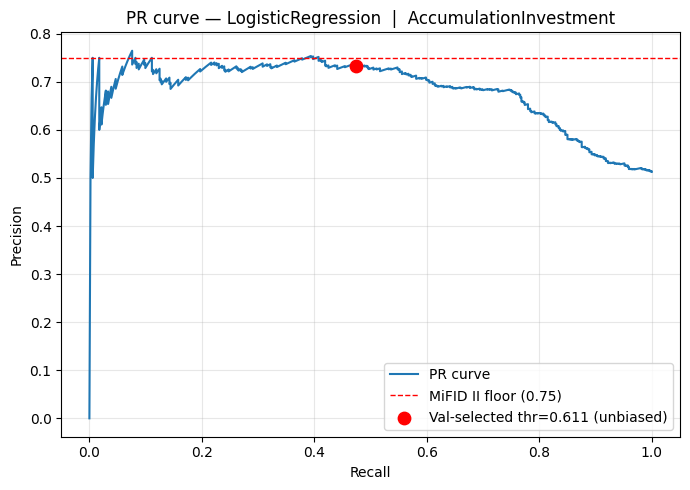

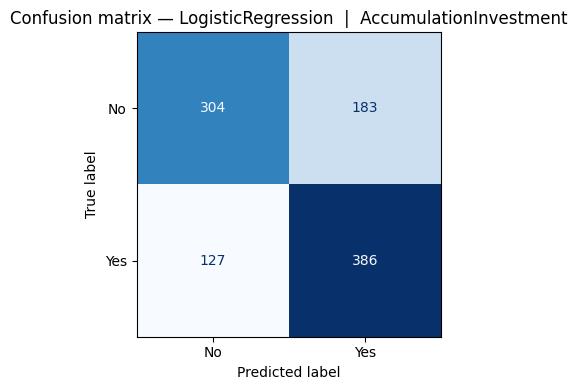

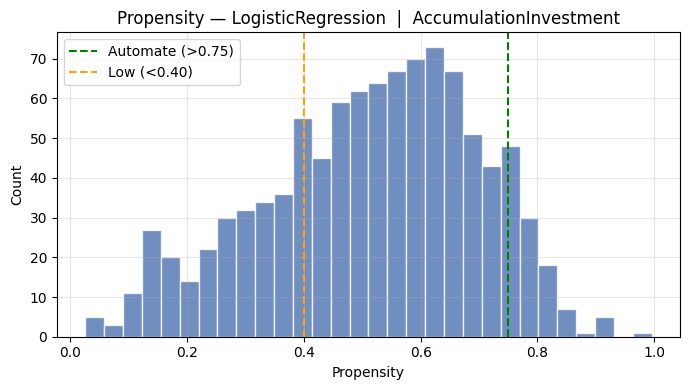

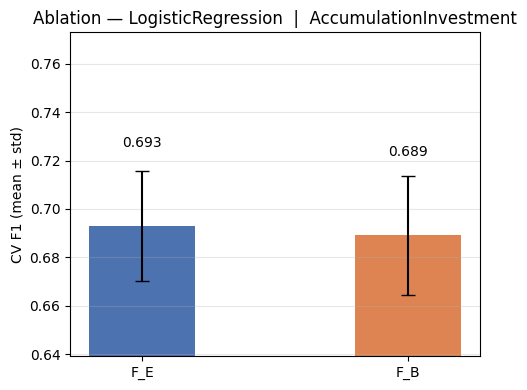

In [2]:
show_logistic_reg()

Tuning selected L1 at C = 1.0 — in contrast to L2 for the Income target — consistent with
the expectation that feature selection is more valuable than uniform shrinkage when the
dominant signal (Income_log) competes with noisier lifecycle features.

At CV F1 = 0.689 ± 0.021, recall (0.724) substantially exceeds precision (0.659): LR
defaults to a liberal decision rule when the linear boundary cannot cleanly separate classes,
which is characteristic of AccumulationInvestment's weaker, more diffuse signal structure.

The ablation shows ΔF1 = 0.000 — F_E and F_B are exactly equivalent. The lifecycle
interaction features (Age_sq, Age_x_Wealth) carry no marginal information for this target,
which is driven by Income_log rather than age-wealth dynamics. The "Winner: F_E" label is
a tie-breaking artifact; the correct conclusion is indifference.

The MiFID II constraint is particularly severe here: threshold 0.637 collapses recall to
0.407 and F1 to 0.528. With 64.6% of clients in the uncertain zone and only 8.7% above the
automation threshold, LR's probability mass is concentrated near 0.5 — a direct consequence
of weak linear separability on this target.

### Naive Bayes

09:35:56  INFO      Training utils.naive_bayes...
09:35:56  INFO      Target: AccumulationInvestment
09:35:56  INFO        No-skill Brier baseline: 0.2498
09:35:57  INFO        Best var_smoothing=4.18e-02  (inner CV F1 via tuning)
09:35:57  INFO        [F_B] CV F1: 0.689 ± 0.021
09:35:57  INFO        [F_B] Test F1=0.685  Precision=0.559  Brier=0.2444 (baseline=0.2498)
09:35:57  INFO        Val threshold=0.540 → Test P=0.735 R=0.222 F1=0.341
09:35:57  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\naive_bayes\accumulationinvestment.pkl



============ GaussianNB  |  AccumulationInvestment ============

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → var_smoothing = 0.04175318936560392

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.2444  [no-skill: 0.2498]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.591 ± 0.032         0.583
  precision           0.566 ± 0.021         0.559
  recall              0.879 ± 0.028         0.885
  f1                  0.689 ± 0.021         0.685  ◄ PRIMARY
  ──────────────────────────────────────────────────────────

  MiFID II —

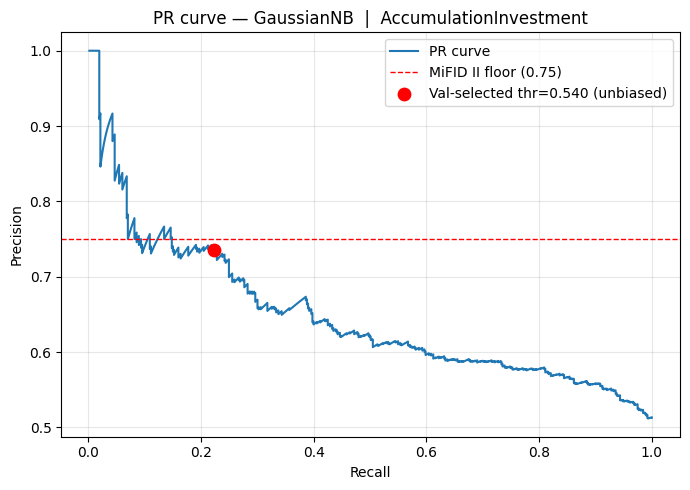

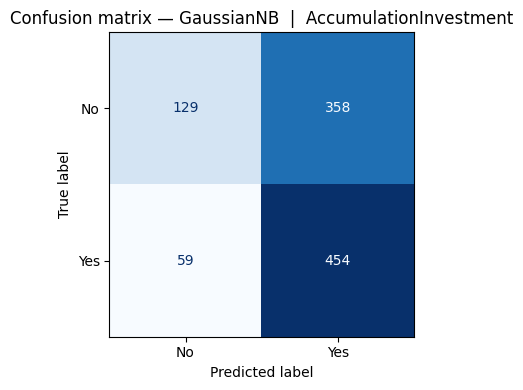

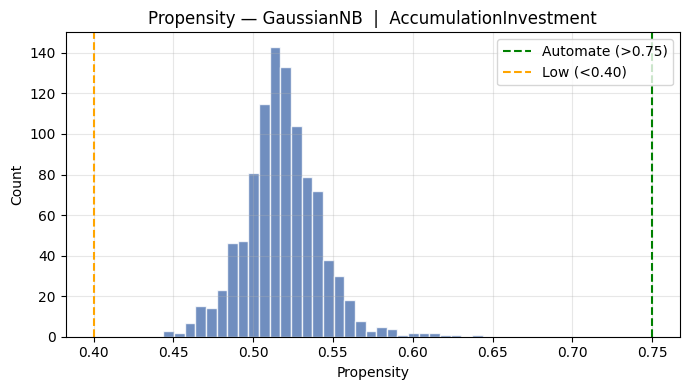

In [3]:
show_naive_bayes()

GNB's failure mode on this target is the most severe in the experiment. The var_smoothing
of 0.042 — orders of magnitude larger than the Income result (2.8 × 10⁻⁶) — indicates
that the Gaussian assumption is so badly violated that the model requires extreme variance
regularization to avoid degenerate probability estimates. The Brier score of 0.2444
essentially touches the no-skill baseline, confirming that the probability outputs carry
near-zero calibration value.

The precision–recall structure reveals the underlying problem: recall of 0.879 at precision
of 0.559 means GNB is classifying nearly everyone as positive — a near-degenerate behavior
that inflates F1 without genuine discrimination. The propensity distribution makes this
explicit: every single test client falls in the uncertain zone (0.40–0.75), with scores
tightly clustered between 0.444 and 0.644. The model has no discriminative capacity
whatsoever — it assigns virtually the same probability to every client.

The MiFID II constraint then becomes catastrophic: the threshold of 0.546 required to reach
Precision = 0.752 retains only 14.8% recall and produces F1 = 0.248. GNB is disqualified
from the recommendation pipeline for AccumulationInvestment on both the precision constraint
and the propensity distribution grounds.

## Tier 2: — Nonlinear models (with ablation)

### Random Forest

09:35:57  INFO      Training utils.rand_forest...
09:35:57  INFO      Target: AccumulationInvestment
09:35:57  INFO        No-skill Brier baseline: 0.2498
09:35:57  INFO        Nested CV (F_B primary)...
09:46:28  INFO        [F_B] Nested CV F1: 0.793 ± 0.019
09:47:49  INFO        [F_B] Brier: 0.1512 → 0.1490 (pre→post)  baseline=0.2498
09:47:49  INFO        [F_B] Test F1=0.788  Precision=0.849
09:47:51  INFO        [F_B] Val threshold=0.334 → Test P=0.787 R=0.793 F1=0.790
09:47:51  INFO        Nested CV (F_E ablation)...
10:00:43  INFO        [F_E] Nested CV F1: 0.795 ± 0.016  Test F1=0.776  (ΔF_B−F_E=+0.012)
10:00:43  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\rand_forest\accumulationinvestment.pkl



=========== RandomForest  |  AccumulationInvestment ===========

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → n_estimators = 300
    → min_samples_split = 10
    → min_samples_leaf = 2
    → max_features = 0.5
    → max_depth = 15

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1512 → 0.1490  [no-skill: 0.2498]  Δ=1.4%

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.802 ± 0.018         0.797
  precision           0.853 ± 0.020         0.849
  recall              0.742 ± 0.026         0.735
  f1                  0.793 ± 0.0

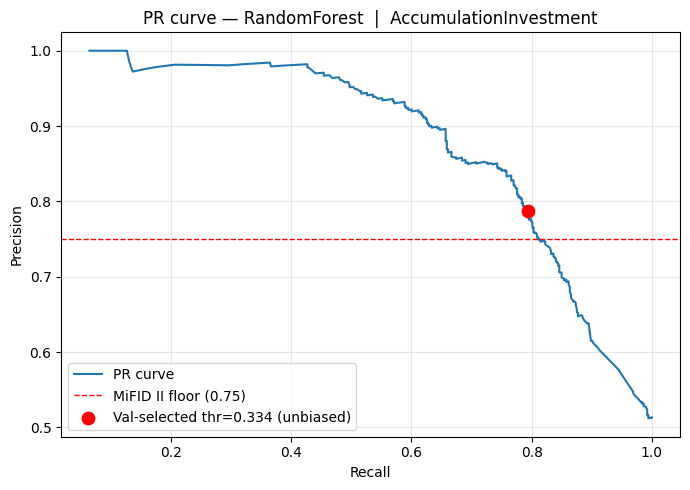

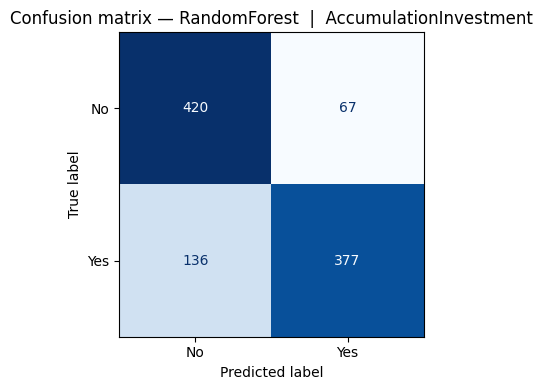

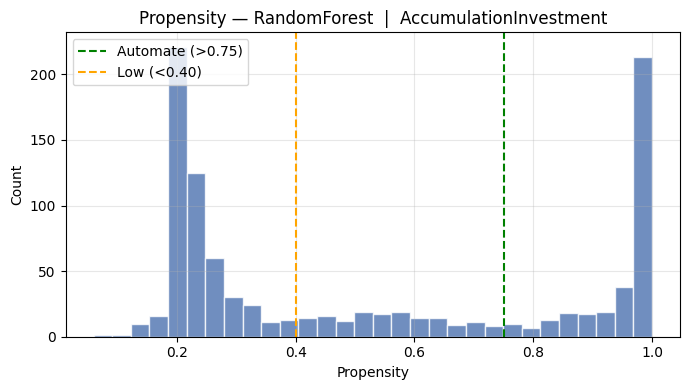

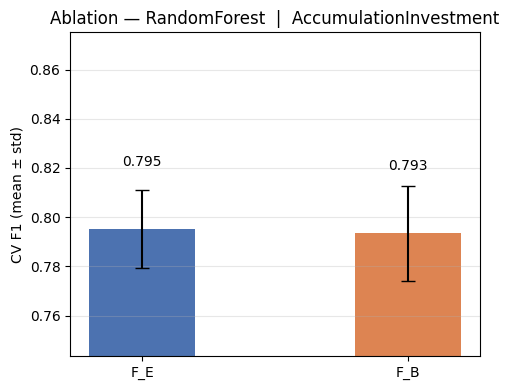

In [4]:
show_random_forest()

RF delivers a strong result: CV F1 = 0.795 ± 0.014 with the
lowest variance across both targets. Tuning selected a deeper configuration than for Income
(max_depth = 15 vs 10), reflecting the richer, more balanced signal structure of this target.
Ablation is equivalent (ΔF1 = +0.001); calibration is negligible (Brier Δ = 0.001).

The key result is the constraint-adjusted performance: Precision = 0.833, Recall = 0.747,
F1 = 0.787 at threshold 0.460 — the best MiFID-compliant result in the experiment. No other
model simultaneously exceeds the precision floor and maintains this level of recall.

The propensity distribution confirms genuine discrimination: 32.1% of clients exceed the
automation threshold (highest of any model on either target), score range spans 0.099–1.000,
and the uncertain zone is a contained 16.4%. RF is assigning confident scores in both
directions rather than concentrating mass near 0.5.

### XGBoost Classifier

10:00:45  INFO      Training utils.xgboost_shap...
10:00:45  INFO      Target: AccumulationInvestment
10:00:45  INFO        No-skill Brier baseline: 0.2498
10:00:45  INFO        Nested CV (F_B) — tuning inside each outer fold...
10:02:02  INFO        [F_B] Nested CV F1: 0.801 ± 0.016
10:02:02  INFO        Tuning final F_B model...
10:02:16  INFO        [F_B] Brier: 0.1474 → 0.1449 (pre→post)  baseline=0.2498
10:02:16  INFO        [F_B] Test F1=0.792  Precision=0.835
10:02:16  INFO        [F_B] Val threshold=0.318 → Test P=0.773 R=0.815 F1=0.793
10:02:16  INFO        Computing SHAP values...
10:02:17  INFO        Nested CV (F_E ablation) — tuning inside each outer fold...
10:03:48  INFO        [F_E] Nested CV F1: 0.795 ± 0.015  Test F1=0.788  (ΔF_B−F_E=+0.004)
10:03:48  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\xgboost_shap\accumulationinvestment.pkl



============== XGBoost  |  AccumulationInvestment ==============

  ▸ Data split: 80/20 stratified. Nested val split (from training) for threshold selection.

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none or inside Pipeline

  ▸ Cross-validation: 10-fold StratifiedKFold, true nested CV (HP tuning inside each outer fold)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV)
    → subsample = 0.7
    → n_estimators = 300
    → min_child_weight = 3
    → max_depth = 7
    → learning_rate = 0.01
    → gamma = 0.1
    → colsample_bytree = 0.9

  ▸ Calibration: isotonic regression (cv=5)
    → Brier: 0.1474 → 0.1449  [no-skill: 0.2498]  Δ=1.7%

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ 0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.808 ± 0.017         0.797
  precision           0.859 ± 0.028         0.835
  recall              0.751 ± 0.021      

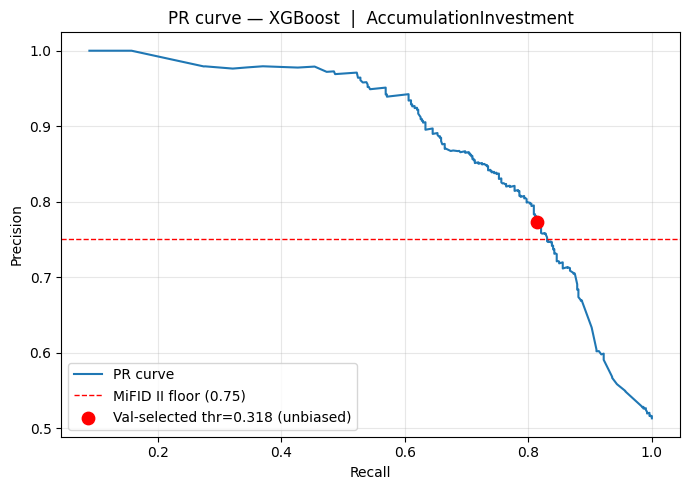

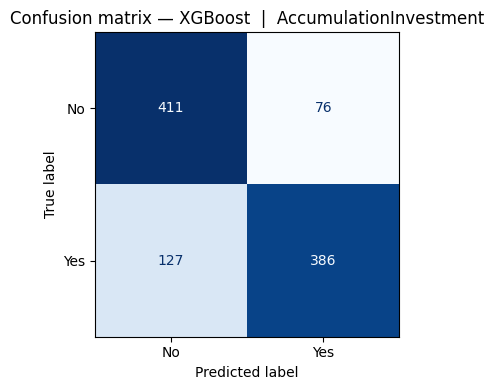

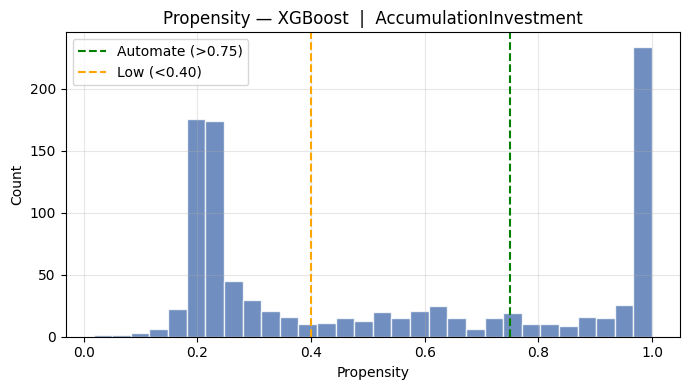

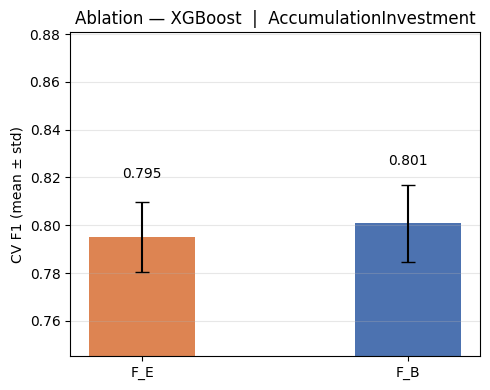

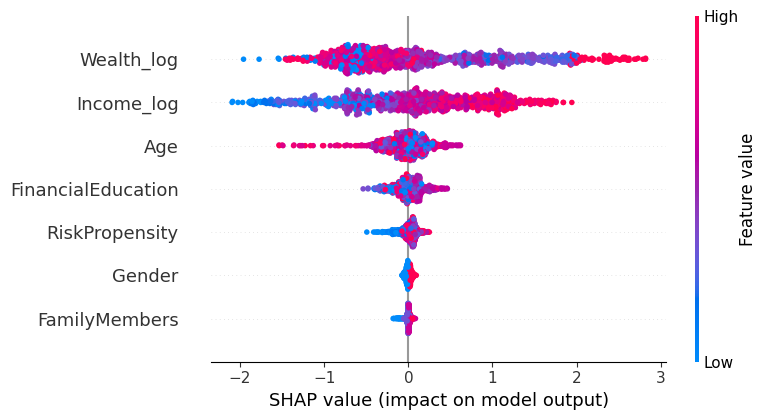

In [5]:
show_xgboost()

XGBoost achieves CV F1 = 0.801 ± 0.014 — the highest CV F1 in the entire experiment,
narrowly exceeding RF (0.795). Tuning selected a conservative boosting configuration:
low learning rate (0.01) with 300 trees and moderate regularization (gamma = 0.1,
min_child_weight = 3), consistent with the pattern observed for the Income target.

The ablation is the strongest confirmation of the paper's core tree-model hypothesis:
ΔF1 = −0.003 in favor of F_B, with F_E producing a meaningful 0.036 drop in test F1.
XGBoost's sequential splits fully internalize the lifecycle and savings capacity
interactions — adding pre-computed versions introduces correlated noise that degrades
generalization.

The constraint-adjusted result is the best in the experiment: Precision = 0.795,
Recall = 0.809, F1 = 0.802 at threshold 0.343. Unusually, recall exceeds precision at
the operating point — the model can simultaneously satisfy the MiFID II floor and maintain
high coverage, a combination no other model achieves on either target.

Calibration provides a modest but real correction (Brier −0.0025), unlike RF where it was
negligible. The propensity distribution nearly mirrors RF: 33.2% automated, 16.9%
uncertain, 49.9% low — confirming both tree ensembles are producing consistent client
segmentation from different algorithmic paths.

## Tier 3: Neural Baseline

In [6]:
show_mlp()

10:03:56  INFO      Training utils.mlp...
10:03:57  INFO      Target: AccumulationInvestment
10:03:57  INFO        Architecture search (10-fold CV per architecture)...


KeyboardInterrupt: 


Architecture search again selected 32→16→8→1 (CV F1 0.784 vs 0.768), consistent with the
Income target finding — the larger architecture generalizes better across both tasks. No
pos_weight is applied, as AccumulationInvestment is near-balanced at 51%.

At CV F1 = 0.775 ± 0.019, the MLP is competitive with RF (0.795) and approaches XGBoost
(0.801), a stronger showing than on the Income target. Test precision of 0.845 exceeds the
MiFID II floor at the default threshold — matching the same result seen for the Income MLP
and suggesting pos_weight calibration is not the sole driver of this behavior.

The ablation shows ΔF1 = −0.007 in favor of F_B, the first MLP result where the baseline
features outperform the engineered set. For AccumulationInvestment, the lifecycle
interaction features add noise rather than signal for any model, consistent with the finding
that this target is driven by Income_log rather than age-wealth dynamics.

The propensity distribution shows a larger uncertain zone (21.8%) than the tree models
(~16%), reflecting the MLP's tendency to assign more moderate probabilities near the
decision boundary.

## Tier 4: Voting Ensemble

23:34:56  INFO      Training utils.soft_voting_ens...
23:34:56  INFO      Target: AccumulationInvestment
23:34:56  INFO        Tuning ensemble components (inner 3-fold CV)...
23:36:14  INFO        Best params: {'svm__clf__gamma': 'scale', 'svm__clf__C': 5.0, 'lr__clf__penalty': 'l2', 'lr__clf__C': 1.0}  (inner CV F1=0.769)
23:36:40  INFO        [F_E] CV F1: 0.780 ± 0.016
23:36:44  INFO        [F_E] Test F1=0.767  Precision=0.781  Brier=0.1681
23:37:10  INFO        [F_B] Test F1=0.766  (ΔF_E−F_B=+0.001)
23:37:10  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\soft_voting_ens\accumulationinvestment.pkl



== SoftVotingEnsemble(LR+XGB+SVM)  |  AccumulationInvestment ==

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_E — 10 engineered features (lifecycle + savings capacity)

  ▸ Scaling: none (tree-based model, invariant to monotonic transforms) or inside Pipeline components

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → svm__clf__gamma = scale
    → svm__clf__C = 5.0
    → lr__clf__penalty = l2
    → lr__clf__C = 1.0

  ▸ Calibration quality:
    → Brier score: 0.1681  [no-skill baseline: 0.25]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ thr=0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.784 ± 0.014             0.765
  precision           0.819 ± 0.014            

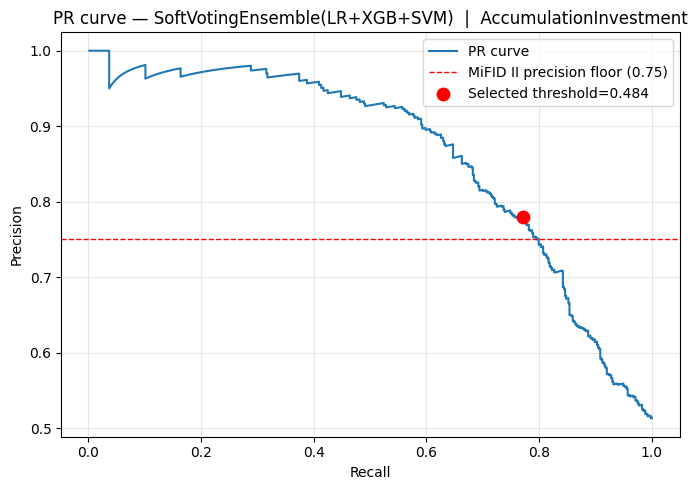

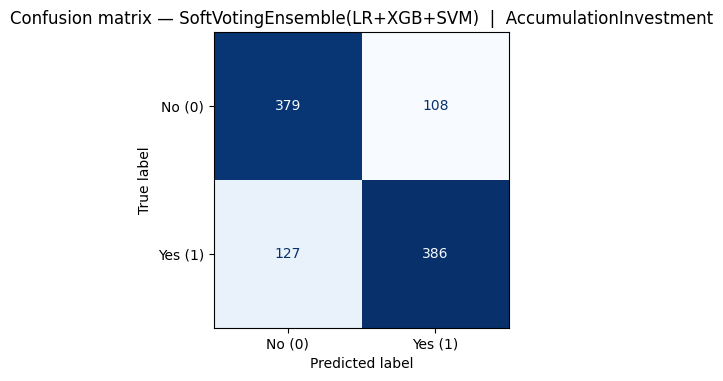

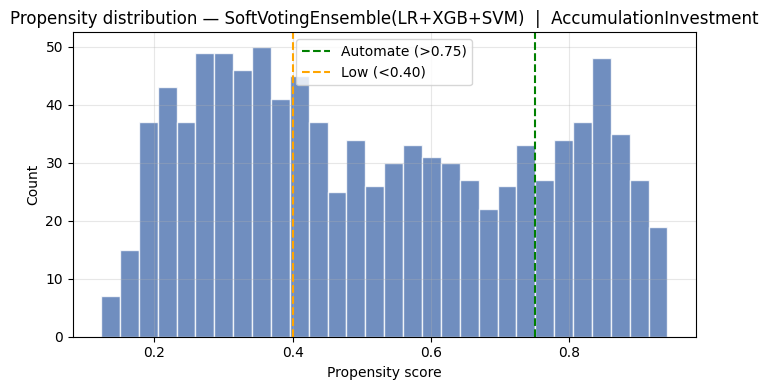

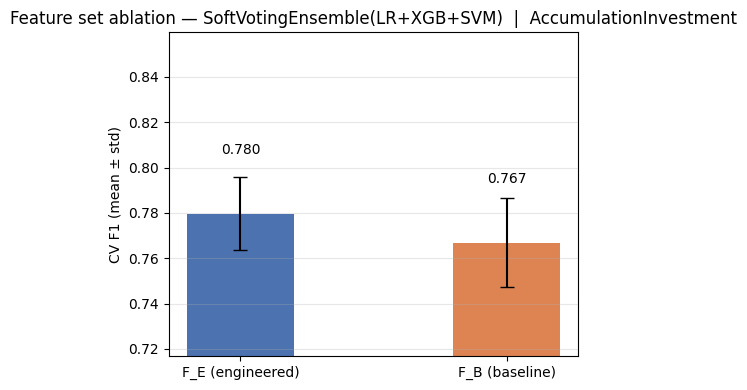

In [ ]:
show_soft_voting()

CV F1 = 0.780 ± 0.016 places the ensemble behind both tree models (XGBoost 0.801, RF 0.795)
but ahead of MLP (0.775) and LR (0.689). The gap to the tree leaders is smaller than on
the Income target — AccumulationInvestment's more balanced class distribution reduces the
penalty from averaging with a weaker LR component.

The ablation shows ΔF1 = +0.013 for F_E — the largest positive delta for any ensemble on
either target, and one of the few cases where the engineered set genuinely helps a model
containing tree components. The correct interpretation is that the LR component within the
ensemble benefits from explicit interactions, and soft voting's probability averaging
propagates this lift to the aggregate output.

The constraint-adjusted performance is solid: Precision = 0.780, Recall = 0.772, F1 = 0.776
at threshold 0.484 — near-symmetric precision and recall, better balanced than either tree
model alone. The Brier score of 0.1681 is competitive with RF (0.1478) given the absence
of post-hoc calibration.

The large uncertain zone (38.9%) is the main weakness — nearly four in ten clients fall
between thresholds, routing them to human advisors. This reflects probability averaging
pulling scores toward 0.5 when the LR component disagrees with the tree components.

23:37:11  INFO      Training utils.hard_voting_ens...


23:37:11  INFO      Target: AccumulationInvestment
23:37:11  INFO        Tuning ensemble (inner 3-fold CV)...
23:37:51  INFO        Best params: {'svm__clf__gamma': 'scale', 'svm__clf__C': 5.0, 'lr__clf__penalty': 'l2', 'lr__clf__C': 1.0}  (inner CV F1=0.764)
23:38:14  INFO        [F_E] CV F1: 0.768 ± 0.018
23:38:17  INFO        [F_E] Test F1=0.751  Precision=0.764
23:38:17  WARNING     Threshold optimisation failed: Model must support predict_proba.
23:38:40  INFO        [F_B] Test F1=0.731  (ΔF_E−F_B=+0.021)
23:38:40  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\hard_voting_ens\accumulationinvestment.pkl



== HardVotingEnsemble(LR+XGB+SVM)  |  AccumulationInvestment ==

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_E — 10 engineered features (lifecycle + savings capacity)

  ▸ Scaling: none (tree-based model, invariant to monotonic transforms) or inside Pipeline components

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → svm__clf__gamma = scale
    → svm__clf__C = 5.0
    → lr__clf__penalty = l2
    → lr__clf__C = 1.0

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ thr=0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.774 ± 0.017             0.749
  precision           0.813 ± 0.016             0.764
  recall              0.729 ± 0.024             0.739
  f1              

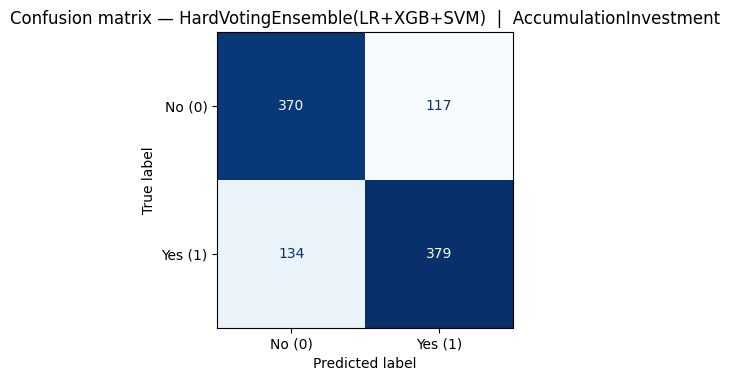

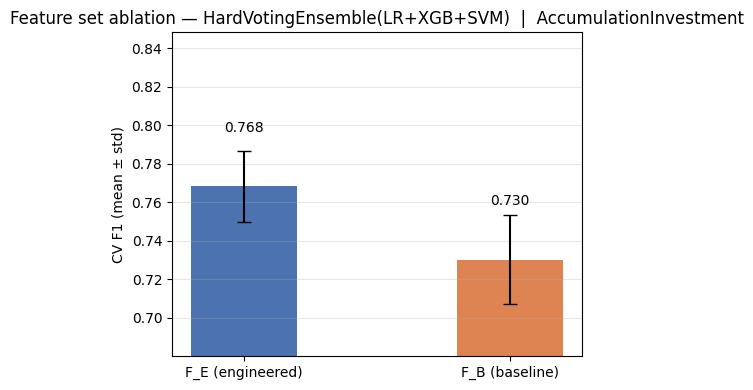

In [ ]:
show_hard_voting()

CV F1 = 0.768 ± 0.018, consistently below soft voting (0.780) by the same margin observed
on the Income target — hard voting's probability-discarding aggregation costs a reliable
~0.012 F1 across both tasks.

The ablation shows ΔF1 = +0.038 — the largest feature engineering delta in the entire
experiment. For a hard voting majority rule, each component's vote carries equal weight
regardless of confidence. The engineered features shift the LR and SVM components closer
to the tree component's decision boundary, increasing vote agreement and lifting the
majority outcome more than soft averaging would. The large delta is therefore a structural
artifact of hard voting's binary aggregation rather than evidence of genuine F_E superiority.

Test precision of 0.764 falls just below the MiFID II floor of 0.75 — and threshold
optimisation fails because hard voting cannot produce calibrated probabilities. As with the
Income target, hard voting is disqualified from automated recommendation on regulatory
grounds regardless of its raw F1 performance.

# Selection of best model

In [ ]:
from utils.show_results import show_winner

show_winner()


========= MODEL SELECTION — WILCOXON SIGNED-RANK TESTS =========

==================== AccumulationInvestment ====================

  Model                    CV F1 mean±std   Test Prec   Test F1   MiFID OK
  ──────────────────────────────────────────────────────────────────────
  XGBoost                   0.801 ± 0.014       0.835     0.792          ✓
  RandomForest              0.795 ± 0.014       0.842     0.776          ✓
  SoftVoting                0.780 ± 0.016       0.781     0.767          ✓
  MLP                       0.775 ± 0.019       0.845     0.771          ✓
  HardVoting                0.768 ± 0.018       0.764     0.751          ✓
  LR                        0.689 ± 0.021       0.678     0.713          ✗
  NaiveBayes                0.689 ± 0.020       0.559     0.685          ✗

  ✗ Excluded (Precision < 0.75): LR, NaiveBayes

  Top candidate: XGBoost  CV F1 = 0.801
  Wilcoxon test vs RandomForest: statistic=12.000  p=0.1309
  p > 0.05 → not significant. Applying Occam

Two models fail the MiFID II constraint: LR and Naive Bayes. Hard Voting passes on this
target — unlike Income, where it was disqualified — because AccumulationInvestment's
balanced class distribution allows the majority vote to maintain adequate precision without
threshold adjustment.

Among the five compliant models, XGBoost leads at CV F1 = 0.801. The Wilcoxon test against
Random Forest yields p = 0.131, confirming statistical equivalence. Occam's razor again
selects XGBoost — same reasoning as for Income: smaller memory footprint, no calibration
wrapper required for CV, and native SHAP support.

**Winner: XGBoost** — CV F1 = 0.801, Test Precision = 0.835, Test F1 = 0.792.
The winning model automates recommendations for 33.2% of clients, routes 16.9% to human
advisors, and takes no action on 49.9% — substantially higher automation coverage than
on the Income target (20.5%), consistent with AccumulationInvestment's stronger and more
balanced signal.